In [1]:
import numpy as np
from scipy.stats import poisson

def average_upper_limit_poisson(nb, confidence_level=0.9, Ntoy=10_000):
    """
    Stima 'media' del limite superiore a un certo livello di confidenza
    per un numero di eventi osservati con background nb (senza segnale),
    usando una procedura semplificata:
      - Genera Ntoy pseudo-esperimenti con n_obs ~ Poisson(nb)
      - Per ognuno calcola un limite superiore N_limit_i a CL=confidence_level
      - Ritorna la media <N_limit>
    
    Parametri:
      nb : float
        Valore atteso di background
      confidence_level : float
        Livello di confidenza (default 0.9 per 90% CL)
      Ntoy : int
        Numero di pseudo-esperimenti
    Ritorna:
      avg_ul : float
        Valore medio di N_limit (sul totale di Ntoy esperimenti)
    """
    # Genera i conteggi osservati con background nb
    n_obs_array = poisson.rvs(nb, size=Ntoy)

    ul_values = []
    for n_obs in n_obs_array:
        # Limite superiore "naif" a CL usando quantile di Poisson
        # (Si aggiunge +1 per evitare ppf(..., 0))
        ul = poisson.ppf(confidence_level, n_obs + 1)
        
        # Qui stiamo calcolando un limite sul TOTALE eventi (signal+bkg).
        # Se vuoi il limite SOLO sul segnale, fai: max(0, ul - nb).
        # Ma la definizione di "average upper limit" può variare.
        ul_values.append(ul)
    
    avg_ul = np.mean(ul_values)
    return avg_ul

# Esempio di utilizzo
if __name__ == "__main__":
    # Background atteso
    nb = 3.0

    # Numero medio di eventi segnale previsti dal tuo modello
    n_s_mean = 10.0
    
    # Flusso del tuo modello
    Phi_model = 1e-15  # Adatta alle tue unità

    # Calcoliamo l'average upper limit in assenza di segnale
    N_limit_avg = average_upper_limit_poisson(nb, confidence_level=0.9, Ntoy=100000)
    
    # MRF = <N_limit> / n_s
    MRF = N_limit_avg / n_s_mean
    
    # Sensibilità in flusso: Φ₉₀ = Φ_model * MRF
    Phi_90 = Phi_model * MRF
    
    print(f"Background atteso (nb) = {nb}")
    print(f"Segnale atteso (n_s_mean) = {n_s_mean}")
    print(f"Average upper limit <N_limit> (90% CL) = {N_limit_avg:.2f}")
    print(f"MRF = {MRF:.3f}")
    print(f"Phi_90 = {Phi_90:.3e}")


Background atteso (nb) = 3.0
Segnale atteso (n_s_mean) = 10.0
Average upper limit <N_limit> (90% CL) = 6.56
MRF = 0.656
Phi_90 = 6.560e-16


In [39]:
import numpy as np
import math
from scipy.stats import poisson

# Cache per evitare di ricalcolare il limite per lo stesso n_obs
fc_cache = {}

def is_in_acceptance(s, nb, n_obs, CL):
    """
    Data un'ipotesi di segnale s e background nb,
    calcola la regione di accettazione Feldman-Cousins (usando l'ordinamento per R)
    e restituisce True se n_obs è incluso nella regione (al livello CL).
    """
    # Scegliamo un intervallo discreto di n: da 0 a n_max
    n_max = int(max(n_obs + 20, s + nb + 10))
    ns = np.arange(0, n_max + 1)
    
    # Calcola P(n | s+nb)
    p_n = poisson.pmf(ns, s + nb)
    
    # Calcola s_best per ogni n: s_best = max(0, n - nb)
    s_best = np.maximum(0, ns - nb)
    p_best = poisson.pmf(ns, s_best + nb)
    
    # Calcola il rapporto di verosimiglianza R(n; s)
    with np.errstate(divide='ignore', invalid='ignore'):
        R = np.where(p_best > 0, p_n / p_best, 0)
    
    # Ordina gli indici in ordine decrescente di R
    order = np.argsort(-R)
    
    cumulative = 0.0
    accepted = []
    for idx in order:
        cumulative += p_n[idx]
        accepted.append(ns[idx])
        if cumulative >= CL:
            break

    return n_obs in accepted

def fc_upper(n_obs, nb, CL=0.9, s_max=50, tol=1e-3):
    """
    Trova, per un dato n_obs e background nb, il limite superiore sul segnale s
    usando il metodo Feldman-Cousins a livello CL.
    Si utilizza una ricerca per bisezione sull'intervallo s ∈ [0, s_max].
    """
    # Se n_obs è 0, il limite superiore Feldman-Cousins coincide con un certo valore;
    # tuttavia il procedimento bisezione funziona in ogni caso.
    s_low = 0.0
    s_high = s_max
    # Eseguiamo la ricerca finché l'intervallo ha lunghezza > tol
    while s_high - s_low > tol:
        s_mid = 0.5 * (s_low + s_high)
        # Se n_obs è ancora nella regione di accettazione per s_mid, possiamo aumentare s
        if is_in_acceptance(s_mid, nb, n_obs, CL):
            s_low = s_mid
        else:
            s_high = s_mid
    return s_low

def fc_upper_cached(n_obs, nb, CL=0.9):
    """
    Funzione wrapper che utilizza un dizionario cache per fc_upper.
    """
    if n_obs in fc_cache:
        return fc_cache[n_obs]
    else:
        ul = fc_upper(n_obs, nb, CL)
        fc_cache[n_obs] = ul
        return ul

def average_upper_limit_feldman_cousins(nb, confidence_level=0.9, Ntoy=10_000):
    """
    Stima 'media' del limite superiore Feldman-Cousins a un certo livello di confidenza
    per un numero di eventi osservati con background nb (senza segnale), usando una procedura:
      - Genera Ntoy pseudo-esperimenti con n_obs ~ Poisson(nb)
      - Per ognuno calcola il limite superiore N_limit_i tramite il metodo Feldman-Cousins
      - Ritorna la media <N_limit>
    
    Parametri:
      nb : float
        Valore atteso di background.
      confidence_level : float
        Livello di confidenza (default 0.9 per 90% CL).
      Ntoy : int
        Numero di pseudo-esperimenti.
        
    Ritorna:
      avg_ul : float
        Valore medio di N_limit (sul totale di Ntoy esperimenti).
    """
    # Genera i conteggi osservati (usiamo la distribuzione Poisson per simulare n_obs)
    n_obs_array = poisson.rvs(nb, size=Ntoy)
    
    ul_values = []
    for n_obs in n_obs_array:
        ul = fc_upper_cached(n_obs, nb, confidence_level)
        ul_values.append(ul)
    
    avg_ul = np.mean(ul_values)
    return avg_ul

# Esempio di utilizzo
if __name__ == "__main__":
    # Background atteso
    #nb = 0.173 -10
    #nb = 0.193  -20
    #nb = 0.214  -30
    nb = 0.242  #-40
    #nb = 0.315
    # Numero medio di eventi segnale previsti dal tuo modello
    n_s_mean = 3.718e3
    
    # Flusso del tuo modello (adatta le unità)
    #Phi_model = 1e-15

    # Calcola l'average upper limit usando Feldman-Cousins in assenza di segnale
    N_limit_avg = average_upper_limit_feldman_cousins(nb, confidence_level=0.9, Ntoy=10000)
    
    # MRF = <N_limit> / n_s_mean
    MRF = N_limit_avg / n_s_mean
    
    # Sensibilità in flusso: Phi_90 = Phi_model * MRF
    #Phi_90 = Phi_model * MRF
    
    print(f"Background atteso (nb) = {nb}")
    print(f"Segnale atteso (n_s_mean) = {n_s_mean}")
    print(f"Average upper limit <N_limit> (90% CL, Feldman-Cousins) = {N_limit_avg:.2f}")
    print(f"MRF = {MRF:.3f}")
    #print(f"Phi_90 = {Phi_90:.3e}")


Background atteso (nb) = 0.242
Segnale atteso (n_s_mean) = 3718.0
Average upper limit <N_limit> (90% CL, Feldman-Cousins) = 2.64
MRF = 0.001


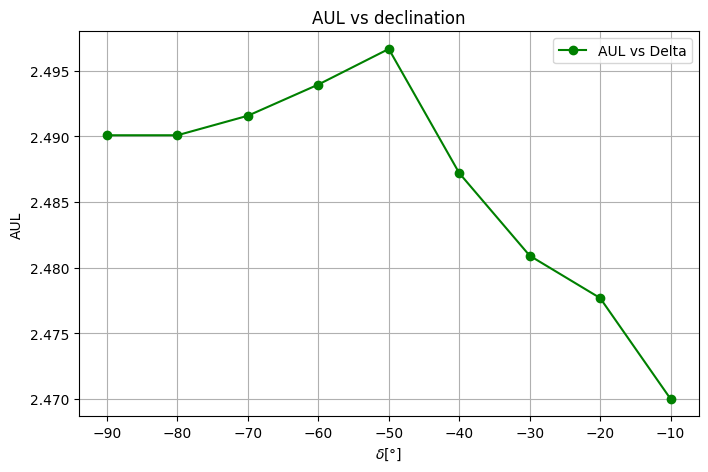

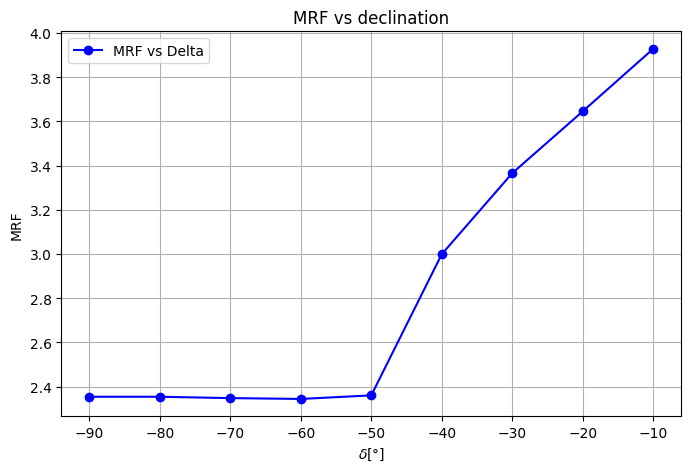

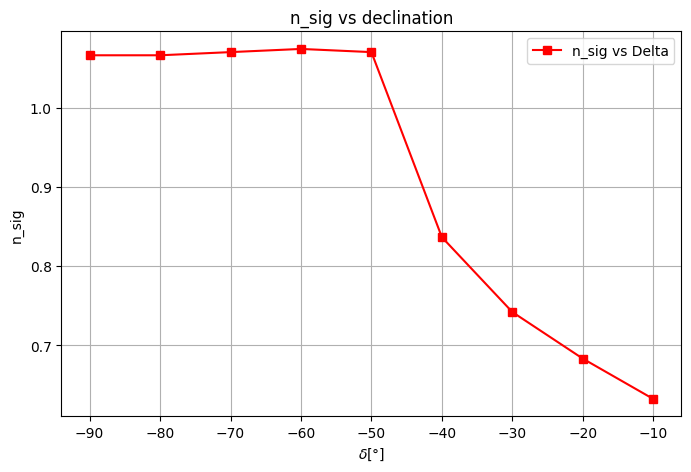

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Liste di valori per n_bk, n_sig e MRF
#n_bk_list = [0.1737795, 0.1934125, 0.2139706, 0.2422314, 0.3152826, 0.2959751, 0.278211, 0.2619555, 0.2619555]
#n_sig_list = [14370.0, 15520.0, 16840.0, 18970.0, 24250.0, 24400.0, 24400.0, 24310.0, 24310.0]
#n_sig_list = [1.437e-2, 1.552e-2, 1.684e-2, 1.897e-2, 2.425e-2, 2.440e-2, 2.440e-2, 2.431e-2, 2.431e-2]
#MRF_list = [0.0001804737273176269, 0.00016816258464959528, 0.00015605397305432645, 0.00013974782263055234, 0.0001119033291272555, 0.00011043506813286942,
#0.00010987981613054225, 0.00010972045282977468, 0.00010972045282977468] 10 Kpc
#MRF_list = [1.804737273176269, 1.6816258464959528, 1.5605397305432645, 1.3974782263055234, 1.119033291272555, 1.1043506813286942, 1.0987981613054225, 1.0972045282977468, 1.0972045282977468]
#n_sig_list = [1.437, 1.552, 1.684, 1.897, 2.425, 2.440, 2.440, 2.431, 2.431] 
# Dati per Anumu
n_sig_anumu = [0.6322, 0.6831, 0.7419, 0.8364, 1.07, 1.074, 1.07, 1.066, 1.066]
MRF_anumu = [3.92757362601086, 3.644897658306548, 3.3651857634846176, 2.998670952549012, 
             2.3602119426061714, 2.344044798820527, 2.3478089739641577, 2.353889381786633, 2.353889381786633]

# Dati per Numu
n_sig_numu = [0.8053, 0.8684, 0.942, 1.061, 1.355, 1.366, 1.37, 1.365, 1.365]
MRF_numu = [3.163749549752713, 2.946276614725238, 2.73820965099567, 2.4422474169967283, 
            1.9462403738061123, 1.9210282792466063, 1.908465212672826, 1.9065451744452753, 1.9065451744452753]


MRF_list = [1.718861071354388, 1.5964448412023353, 1.4732240373920906, 1.3111208048467595, 1.0295451536641387, 1.0221052451502877, 1.0211320632838197, 1.0243014532650758, 1.0243014532650758]
AUL_list = [2.4700033595362556, 2.4776823935460244, 2.4809092789682805, 2.4871961667943028, 2.496646997635536, 2.4939367981667018, 2.49156223441252, 2.4900768328873992, 2.4900768328873992]

# Definizione della declinazione delta da -10 a -90 con lo stesso numero di punti
num_points = len(MRF_list)
delta_list = np.linspace(-10, -90, num_points)

# Plot di AUL vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, AUL_list, marker='o', linestyle='-', color='g', label='AUL vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('AUL')

plt.title('AUL vs declination')
plt.legend()
plt.grid()
plt.show()


# Plot di MRF vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, MRF_anumu, marker='o', linestyle='-', color='b', label='MRF vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('MRF')

plt.title('MRF vs declination')
plt.legend()
plt.grid()
plt.show()

# Plot di n_sig vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list,n_sig_anumu, marker='s', linestyle='-', color='r', label='n_sig vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('n_sig')

plt.title('n_sig vs declination')
plt.legend()
plt.grid()
plt.show()


CALCRATE

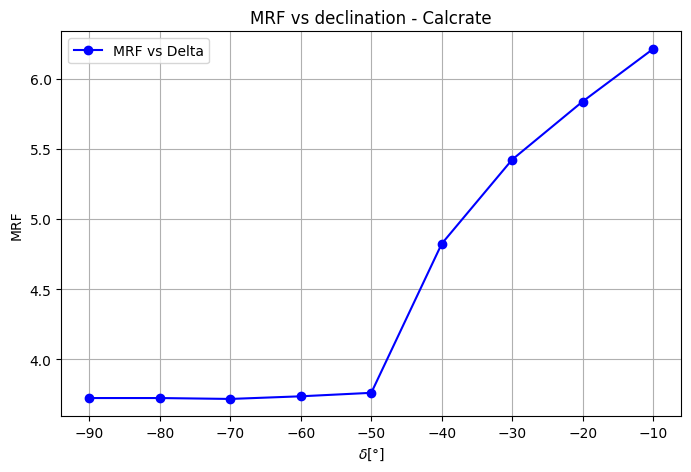

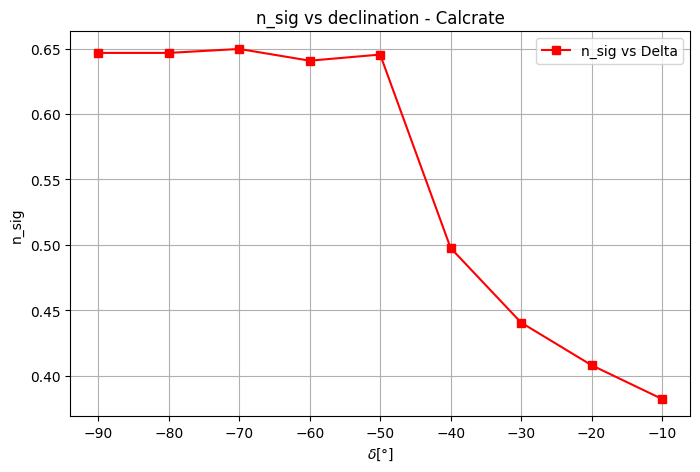

In [12]:


total_sig_list_c = [1.39657, 1.49356, 1.61448, 1.82394, 2.36489, 2.36891, 2.36981, 2.35872, 2.35872]

MRF_list_c = [1.72018, 1.61583, 1.50191, 1.33802, 1.04885, 1.04264, 1.03815, 1.03926, 1.03926]
total_sig_numu_c = [0.382147, 0.407962, 0.440563, 0.497599, 0.645541, 0.640857, 0.649841, 0.646808, 0.646808]
MRF_numu_c = [6.21081, 5.83649, 5.42283, 4.82351, 3.76183, 3.73708, 3.71826, 3.72466, 3.72466]
num_points = len(MRF_numu_c)
delta_list = np.linspace(-10, -90, num_points)
# Plot di MRF vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, MRF_numu_c, marker='o', linestyle='-', color='b', label='MRF vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('MRF')

plt.title('MRF vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

# Plot di n_sig vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list,total_sig_numu_c, marker='s', linestyle='-', color='r', label='n_sig vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('n_sig')

plt.title('n_sig vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

In [2]:
def save_data(filename, data1, data2, header1="Column 1", header2="Column 2"):
    """
    Salva due array di dati in un file di testo con due colonne.

    Parameters:
    filename (str): Nome del file di output.
    data1 (numpy array): Primo array di dati.
    data2 (numpy array): Secondo array di dati.
    header1 (str): Intestazione della prima colonna.
    header2 (str): Intestazione della seconda colonna.

    Output:
    Un file di testo con due colonne: data1 e data2.
    """
    data_to_save = np.column_stack((data1, data2))  # Combina i dati in due colonne
    header = f"{header1}   {header2}"  # Crea l'intestazione dinamicamente
    np.savetxt(filename, data_to_save, fmt="%.6e", header=header, comments='')






Test SENSITIVITY

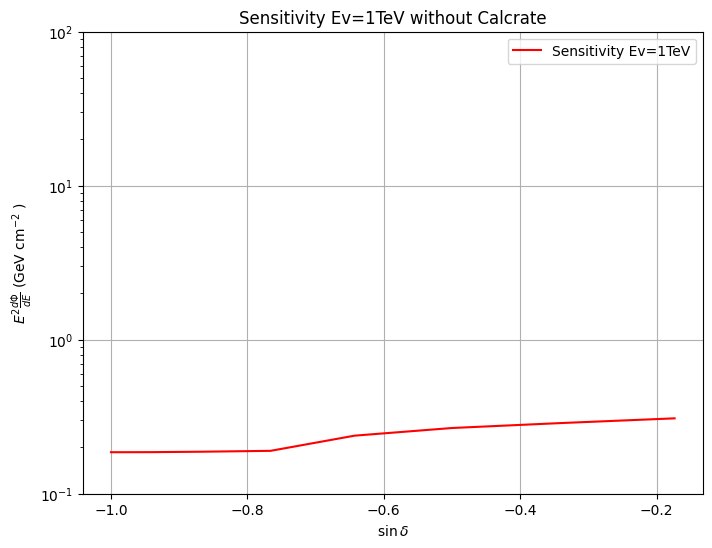

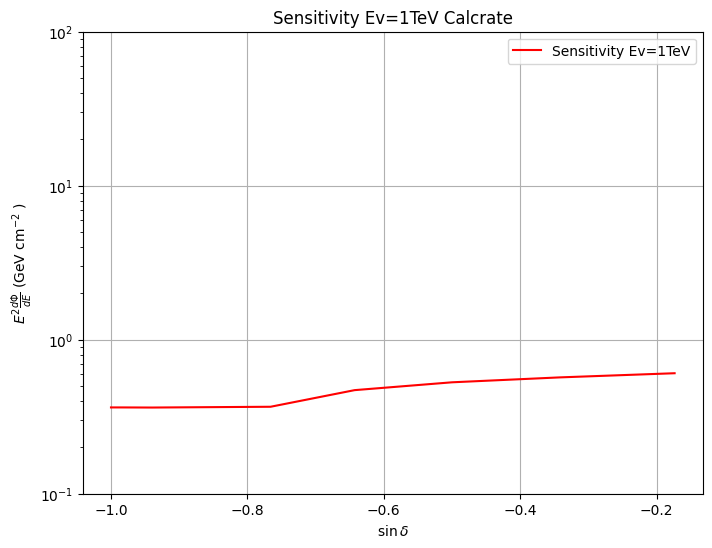

[array([0.3086552]), array([0.28743856]), array([0.26713956]), array([0.2382655]), array([0.18987508]), array([0.18741539]), array([0.18618974]), array([0.18600242]), array([0.18600242])]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dati di input
#num_points = len(MRF_list)
#delta_list = np.linspace(-90, -10, num_points)
  # Converti in sin(δ) in radianti


d = 1*3.086e24
d_c = 1*3.086e22
# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)
#data = np.loadtxt("flux_IIn.dat", skiprows=1)
#dN_dEv = data[15, 1]/1e9
#flux = dN_dEv/(4*np.pi*d**2)

#sensitivity = [flux * mrf for mrf in MRF_list]
if data[-1, -1] == 1:
    Ev_all = data[:, 0]
    Ev = Ev_all[Ev_all == 1.07461e12]  # Seleziona valori di Ev maggiori di 3e8
    Ev_c = Ev_all[Ev_all > 0.3e8]/1e9
    #Selezione del valore specifico di Ev
    S_IIn_start = 1e5 * pow(10., 0.1 * (25 - 1)) 
    S_IIn_stop = 1e5 * pow(10., 0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start
    dN_dEv = data[:, 7]
    dN_dEv_c = data[:, 7][Ev_all>0.3e8]
    dN_dEv = dN_dEv * delta
    dN_dEv = dN_dEv[Ev_all == 1.07461e12]
    
    flux = Ev**2*dN_dEv/(6*1e9*4*np.pi*d**2)
    flux_c = dN_dEv_c*1e9/(6*4*np.pi*d_c**2)
    
    # Esempio di utilizzo per Ev_c e dN_dEv_c
    save_data("flux_c1.txt", Ev_c, flux_c, header1="Ev_c [GeV]", header2="dN_dEv_c [s^-1 GeV^-1]")
# Calcola la sensibilità per ogni δ
    sensitivity = [flux * mrf for mrf in MRF_numu]
    sensitivity_c = [flux * mrf for mrf in MRF_numu_c]


sin_delta = np.sin(np.radians(delta_list))
# Plot della sensibilità in funzione di sin(δ)
plt.figure(figsize=(8, 6))
plt.plot(sin_delta, sensitivity, color='red', label="Sensitivity Ev=1TeV")

# Formattazione del grafico
plt.xlabel(r"$\sin \delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV cm$^{-2}$ )")
plt.yscale("log")  # Scala logaritmica
plt.ylim(1e-1,1e2)
#plt.xscale("linear")  # x non serve in log
plt.grid(True)
plt.title('Sensitivity Ev=1TeV without Calcrate')
plt.legend()  # Aggiunge la legenda
plt.show()

# Plot della sensibilità in funzione di sin(δ)
plt.figure(figsize=(8, 6))
plt.plot(sin_delta, sensitivity_c, color='red', label="Sensitivity Ev=1TeV")

# Formattazione del grafico
plt.xlabel(r"$\sin \delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV cm$^{-2}$ )")
plt.yscale("log")  # Scala logaritmica
plt.ylim(1e-1,1e2)
#plt.xscale("linear")  # x non serve in log
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Calcrate')
plt.legend()  # Aggiunge la legenda
plt.show()
print(sensitivity)



Anumu

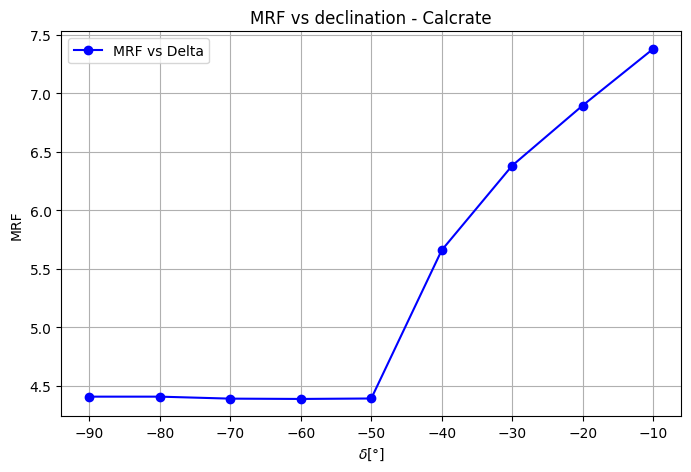

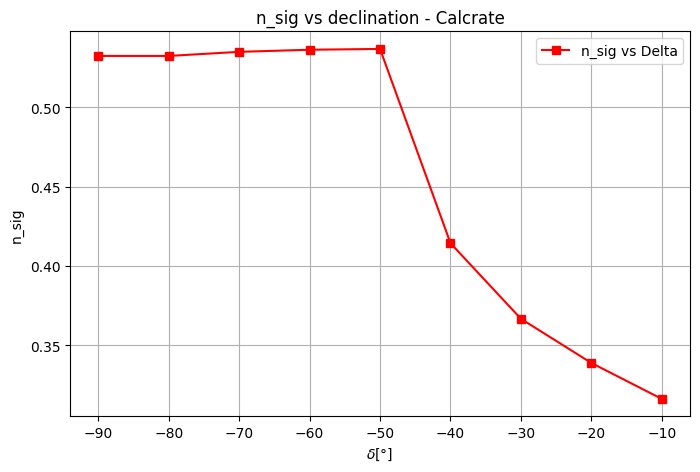

In [3]:

total_sig_anumu_c = [0.31614, 0.338821, 0.366676, 0.41437, 0.536904, 0.536398, 0.535064, 0.532494, 0.532494]
MRF_anumu_c = [7.37783, 6.89455, 6.38082, 5.65836, 4.39103, 4.38719, 4.38978, 4.40676, 4.40676]
num_points = len(MRF_anumu_c)
delta_list = np.linspace(-10, -90, num_points)
# Plot di MRF vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, MRF_anumu_c, marker='o', linestyle='-', color='b', label='MRF vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('MRF')

plt.title('MRF vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

# Plot di n_sig vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list,total_sig_anumu_c, marker='s', linestyle='-', color='r', label='n_sig vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('n_sig')

plt.title('n_sig vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

8.466484852816438e-10


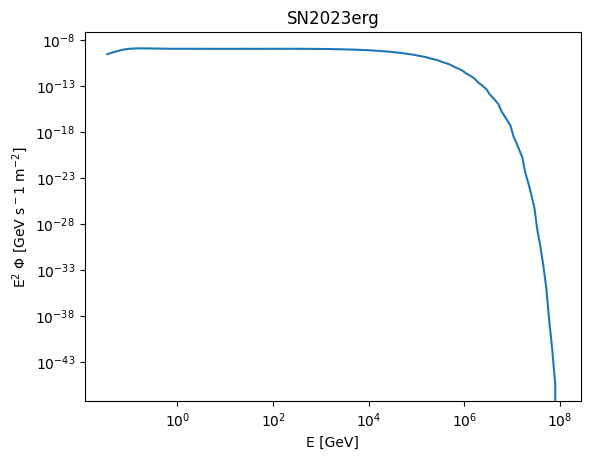

In [17]:
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('flux_c_SN2022wqo.txt', skiprows=1)
e =  data[:,0]
f = data[:,1]
plt.plot(e,e**2*f)
plt.xlabel('E [GeV]')
#plt.xlim(1e-1,1e6)
print(data[24,1])
plt.title('SN2023erg')
plt.ylabel(r'E$^{2}$ $\Phi$ [GeV s$^-1$ m$^{-2}$]')
plt.xscale('log')
plt.yscale('log')

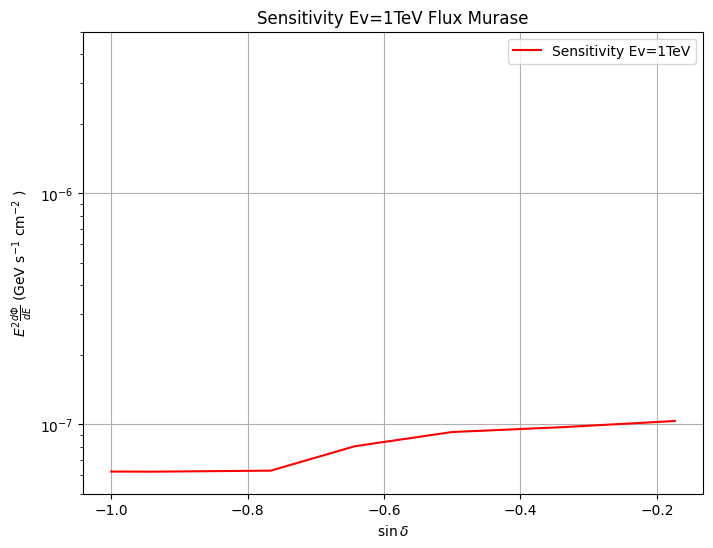

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Distanze
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate


# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

# Definizione MRF
MRF_tot = np.array([3.44035, 3.23166, 3.0832, 2.67603, 2.0977, 2.08528, 2.07631, 2.07851, 2.07851])
MRF_2 = np.array([1.60092, 1.54361, 1.44224, 1.25664, 0.902442, 1.00235, 1.03744, 1.0846, 1.0846])

# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro

    # Selezione dei valori vicini a 1 TeV
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_all>0.3e8]/1e9
    dN_dEv = dN_dEv[Ev_all>0.3e8]

    # Se il valore di Ev è vuoto, segnala errore
    if Ev.size == 0:
        print("Errore: Nessun valore di Ev corrisponde a 1 TeV!")
    else:
        # Calcolo intervallo delta tra i blocchi
        S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
        S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
        delta = S_IIn_stop - S_IIn_start

        # Calcolo del flusso
        #dN_dEv *= delta
        flux = dN_dEv * 1e9 / (6 * 4 * np.pi * d_m**2)
        flux_c = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
        
        # Sensibilità
        #sensitivity = flux_c * MRF_tot
        save_data("flux_c2.txt", Ev, flux, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")


        # Definizione degli angoli δ
        delta_list = np.linspace(-10, -90, len(MRF_tot))
        sin_delta = np.sin(np.radians(delta_list))

        # Plot 1: Sensibilità (Flux Murase)
        plt.figure(figsize=(8, 6))
        plt.plot(sin_delta, sensitivity, color='red', label="Sensitivity Ev=1TeV")
        plt.xlabel(r"$\sin \delta$")
        plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
        plt.yscale("log")
        plt.ylim(5e-8,5e-6)
        plt.grid(True)
        plt.title('Sensitivity Ev=1TeV Flux Murase')
        plt.legend()
        plt.show()


    
print()


SN IIn model Murase



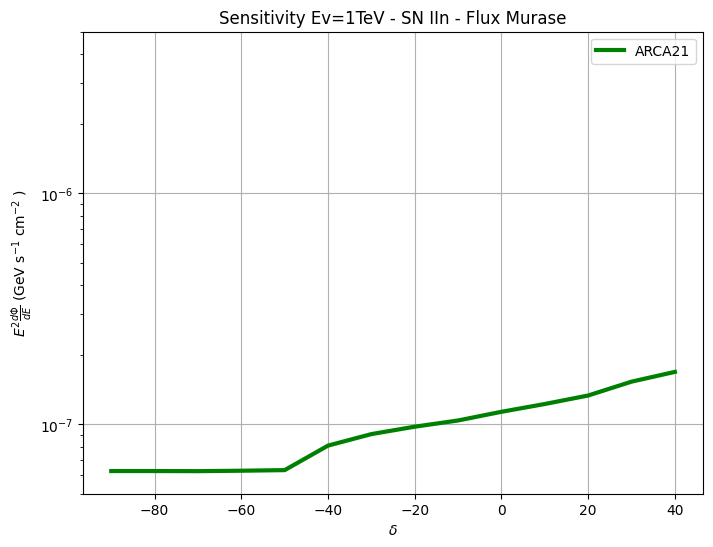

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate


# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

# Definizione MRF
MRF = np.array([2.08928, 2.08928, 2.08708, 2.09614, 2.10845,
2.69245, 3.01953, 3.25104, 3.45896, 3.77155,
4.07613, 4.43628, 5.09276, 5.61407
])
mrf_27 = [
    2.07851, 2.07851, 2.07631, 2.08528, 2.0977,
    2.67603, 3.00382, 3.23166, 3.44035, 3.75221,
    4.06071, 4.41866, 5.07397, 5.59414
]



# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro
    Ev_c = Ev_all[Ev_all > 0.3e8]/1e9
    # Selezione dei valori vicini a 1 TeV
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_mask]
    dN_dEv = dN_dEv[Ev_mask]
    dN_dEv_c = data[:, 7][Ev_all>0.3e8]
   
    # Calcolo intervallo delta tra i blocchi
    S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
    S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start

    # Calcolo del flusso
    #dN_dEv *= delta
    #SN2021uha
    flux_c = dN_dEv_c * 1e9 / (6 * 4 * np.pi * d_m**2)
    flux = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
  
    # Sensibilità
    #SN2021uha
    sensitivity = flux * MRF
    sensitivity_27 = flux * mrf_27
    
   
    #save_data("flux_IIn.txt", Ev_c, flux_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")


    # Definizione degli angoli δ
    delta_list = np.linspace(-90, 40, len(MRF))
    sin_delta = np.sin(np.radians(delta_list))
    #highlight_x = np.sin(np.radians(-25))
   
    # Plot 1: Sensibilità (Flux Murase)
    plt.figure(figsize=(8, 6))
    plt.yscale("log")
    #plt.plot(delta_list, sensitivity_27, marker='o',color='blue', label="aanet 2.7")
    plt.plot(delta_list, sensitivity, linewidth=3 ,color='green', label="ARCA21")
    
    plt.xlabel(r"$\delta$")
    plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
    
    plt.ylim(5e-8,5e-6)
    plt.grid(True)
    plt.title('Sensitivity Ev=1TeV - SN IIn - Flux Murase')
    plt.legend()
    plt.show()

        
print()


ARCA8+ARCA19+ARCA21

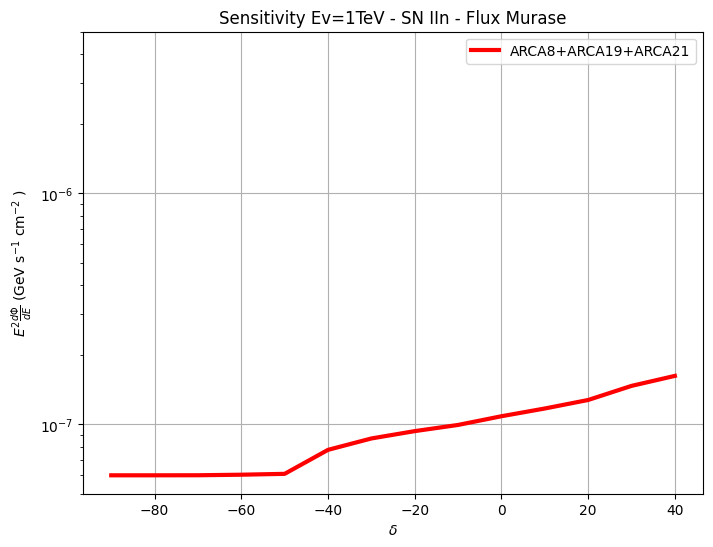

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate


# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

# Definizione MRF
MRF_8_19_21 = [
    2.00246,  # decl = -90°
    2.00246,  # decl = -80°
    2.00356,  # decl = -70°
    2.01443,  # decl = -60°
    2.03193,  # decl = -50°
    2.58071,  # decl = -40°
    2.89101,  # decl = -30°
    3.11065,  # decl = -20°
    3.30816,  # decl = -10°
    3.60784,  # decl =   0°
    3.89722,  # decl = +10°
    4.24245,  # decl = +20°
    4.88266,  # decl = +30°
    5.39486 # decl = +40°
]




# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro
    Ev_c = Ev_all[Ev_all > 0.3e8]/1e9
    # Selezione dei valori vicini a 1 TeV
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_mask]
    dN_dEv = dN_dEv[Ev_mask]
    dN_dEv_c = data[:, 7][Ev_all>0.3e8]
   
    # Calcolo intervallo delta tra i blocchi
    S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
    S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start

    # Calcolo del flusso
    #dN_dEv *= delta
    #SN2021uha
    flux_c = dN_dEv_c * 1e9 / (6 * 4 * np.pi * d_m**2)
    flux = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
  
    # Sensibilità
   
    sensitivity_tot = flux * MRF_8_19_21
    
    
   
    #save_data("flux_IIn.txt", Ev_c, flux_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")


    # Definizione degli angoli δ
    delta_list = np.linspace(-90, 40, len(MRF_8_19_21))
    sin_delta = np.sin(np.radians(delta_list))
    #highlight_x = np.sin(np.radians(-25))
   
    # Plot 1: Sensibilità (Flux Murase)
    plt.figure(figsize=(8, 6))
    plt.yscale("log")
    
    plt.plot(delta_list, sensitivity_tot, linewidth=3, color='red', label="ARCA8+ARCA19+ARCA21")
    #plt.plot(delta_list, sensitivity, linewidth=1 ,color='green', label="ARCA21")

    plt.xlabel(r"$\delta$")
    plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
    
    plt.ylim(5e-8,5e-6)
    plt.grid(True)
    plt.title('Sensitivity Ev=1TeV - SN IIn - Flux Murase')
    plt.legend()
    plt.show()

        
print()


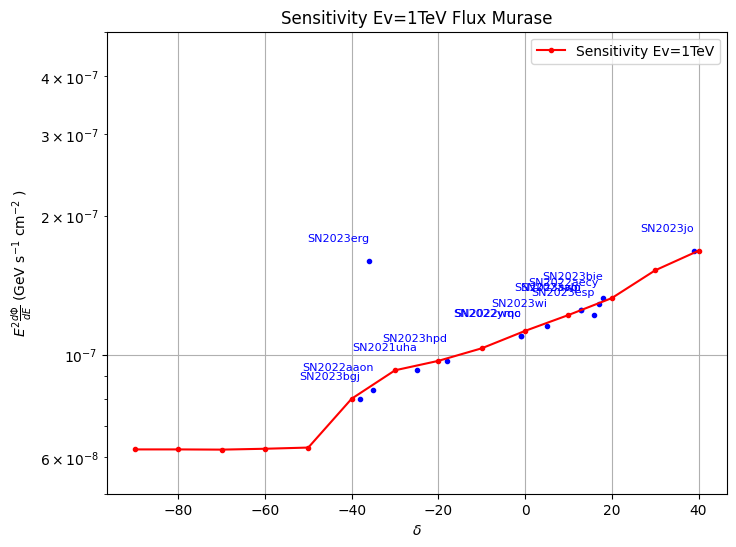

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Funzione di salvataggio dati (puoi personalizzarla se necessario)
'''def save_data(filename, x, y, header1="", header2=""):
    header = f"{header1}\t{header2}"
    data = np.column_stack((x, y))
    np.savetxt(filename, data, header=header)'''

# Dati MRF 
MRF_tot = np.array([5.59414,5.07397,4.41866,4.06071,3.75221,3.44035, 3.23166, 3.0832, 2.67603, 2.0977, 2.08528, 2.07631, 2.07851, 2.07851])
#d modello
d = 1 * 3.086e24 #1Mpc in cm
# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12  # eV

# Dati sorgenti SN organizzati in un dizionario
# Per ogni sorgente definiamo: distanza in cm e in m, fattore moltiplicativo per il plot e declinazione
sn_sources = {
    'SN2021uha': {'d_cm': 33.8 * 3.086e24, 'd_m': 33.8, 'MRF': 3529.99, 'dec': -25},
    'SN2023esp': {'d_cm': 34.3 * 3.086e24, 'd_m': 34.3, 'MRF': 4780.31, 'dec': 16},
    'SN2023erg': {'d_cm': 286.9 * 3.086e24,  'd_m':286.9 ,  'MRF': 437578,  'dec': -36},
    'SN2023hpd': {'d_cm': 84.8 * 3.086e24, 'd_m': 84.8, 'MRF': 23235,  'dec': -18},
    'SN2023bie': {'d_cm': 265.5 * 3.086e24, 'd_m': 265.5 , 'MRF': 311473, 'dec': 18},
    'SN2023bgj': {'d_cm': 235.6 * 3.086e24, 'd_m': 235.6 , 'MRF': 148540, 'dec': -38},
    'SN2023awp': {'d_cm': 58.3 * 3.086e24,  'd_m': 58.3 ,  'MRF': 14173.5, 'dec': 13},
    'SN2023abi': {'d_cm': 394 * 3.086e24,   'd_m': 394 ,   'MRF': 647340, 'dec': 13},
    'SN2023wi':  {'d_cm': 402.6 * 3.086e24, 'd_m': 402.6 , 'MRF': 623643, 'dec': 5},
    'SN2023jo':  {'d_cm': 55.7 * 3.086e24,  'd_m': 55.7 ,  'MRF': 17355.7, 'dec': 39},
    'SN2022aecy':{'d_cm': 342.6 * 3.086e24, 'd_m': 342.6 , 'MRF': 503086, 'dec': 17},
    'SN2022aaon':{'d_cm': 316.9 * 3.086e24, 'd_m': 316.9 , 'MRF': 281258, 'dec': -35},
    'SN2022ymc': {'d_cm': 119.9 * 3.086e24, 'd_m': 119.9 , 'MRF': 52588.1, 'dec': -1},
    'SN2022wqo': {'d_cm': 400.4 * 3.086e24, 'd_m': 400.4 , 'MRF':  586458, 'dec': -1}
}

# Caricamento dati dal file
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

if data.shape[1] > 7:
    # Estrazione dati dallo spettro
    Ev_all = data[:, 0]        # Energia in eV
    dN_dEv_all = data[:, 7]      # Spettro

    # Selezione dei dati a bassa energia (per il calcolo di flux_c)
    mask_valid = Ev_all 
    Ev_c = Ev_all[Ev_all==E_fixed] / 1e9   # in GeV
    dN_dEv_c = dN_dEv_all[Ev_all==E_fixed]

    # Selezione dei valori vicini a 1 TeV
    mask_fixed = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_all==E_fixed]
    dN_dEv = dN_dEv_all[Ev_all==E_fixed]

    # Calcolo dell'intervallo delta (se necessario)
    S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
    S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start
    
    flux_c = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
        
    sensitivity_model = flux_c * MRF_tot
    # Funzioni per il calcolo del flux:
    # flux_calculation usa la distanza in cm, mentre flux_c usa la distanza in m
    def flux_calc(Ev_val, dN_dEv_val, d_cm):
        return (Ev_val**2 * dN_dEv_val) / (1e9 * 3 * 4 * np.pi * d_cm**2)
    
    def flux_c_calc(dN_dEv_vals, d_m):
        return (dN_dEv_vals * 1e9) / (6 * 4 * np.pi * d_m**2)
    
    # Calcolo flux e flux_c per ciascuna sorgente
    results = {}
    for sn, params in sn_sources.items():
        f = flux_calc(Ev, dN_dEv, params['d_cm'])
        f_c = flux_c_calc(dN_dEv_c, params['d_m'])
        results[sn] = {'flux': f, 'flux_c': f_c}
    
    # Generazione automatica del nome del file: "flux_c_<nome_supernova>.txt"
        '''filename = f"flux_c_{sn}.txt"
        save_data(filename, Ev_c, f_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")
        print(f"Dati salvati in {filename}")'''

    # Calcolo sensitività per SN2021uha e SN2023esp (utilizzando MRF specifici)
    sensitivity_uha = results['SN2021uha']['flux'] * sn_sources['SN2021uha']['MRF']
    sensitivity_esp = results['SN2023esp']['flux'] * sn_sources['SN2023esp']['MRF']
    
    # Definizione degli angoli δ per il plot della sensibilità (lungo l'array MRF)
    delta_list = np.linspace(40, -90, len(MRF_tot))
    
    # Preparazione del plot
    plt.figure(figsize=(8, 6))
    plt.yscale("log")
    
    # Plot delle sorgenti con scatter
    for sn, params in sn_sources.items():
        # Si utilizza il flux calcolato e il moltiplicatore specificato per ottenere il valore da plottare
        y_val = np.array(results[sn]['flux'] * params['MRF'])
        x_val = np.array(params['dec'])
        plt.scatter(x_val, y_val, marker='.', color='blue', zorder=1)
        plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='blue', ha='right')
    
    # Plot della sensibilità per SN2023esp (linea rossa)
    plt.plot(delta_list, sensitivity_model, color='red',marker='.', label="Sensitivity Ev=1TeV")
    
    plt.xlabel(r"$\delta$")
    plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
    plt.ylim(5e-8,5e-7)
    plt.grid(True)
    plt.title('Sensitivity Ev=1TeV Flux Murase')
    plt.legend()
    plt.show()

else:
    print("I dati caricati non hanno il numero di colonne richiesto.")


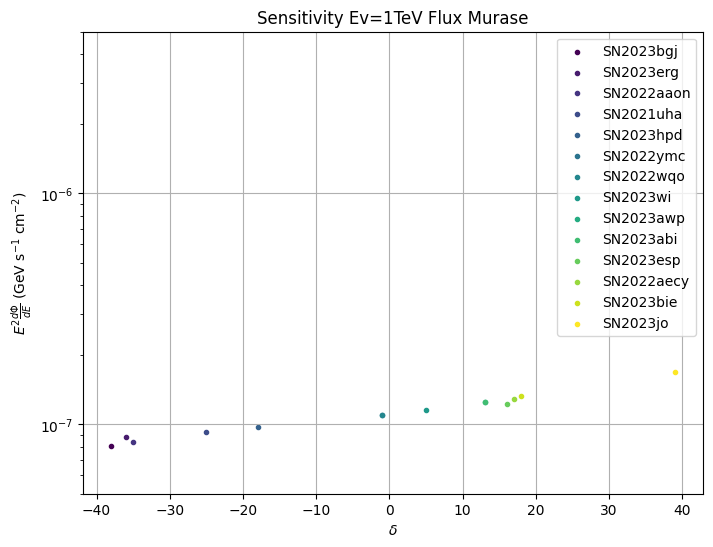

In [5]:
# Ordinare le supernove in base al valore di declinazione (ad esempio, da quello più basso al più alto)
sorted_sn_sources = sorted(sn_sources.items(), key=lambda item: item[1]['dec'])

# Genera una serie di colori usando una colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_sn_sources)))

# Preparazione del plot
plt.figure(figsize=(8, 6))
plt.yscale("log")

# Plot delle sorgenti con scatter, in ordine e con colori diversi
for i, (sn, params) in enumerate(sorted_sn_sources):
    # Calcola il valore da plottare
    y_val = np.array(results[sn]['flux']*params['MRF'])
    # x_val è la declinazione: creiamo un array con il valore singolo ripetuto per ogni elemento di y_val
    x_val = np.full_like(y_val, params['dec'])
    
    # Assegna il colore per questa supernova
    color = colors[i]
    
    # Scatter con il colore specifico
    plt.scatter(x_val, y_val, marker='.', color=color, zorder=1, label=sn)
    # Aggiunge l'etichetta in corrispondenza del primo punto
    # Calcola offset dinamici
    '''AttributeErrorif i % 2 == 0:
    # Posiziona l'etichetta sopra il punto
        plt.text(x_val[0], y_val[0] * 1.2, sn,
             fontsize=9, color=color, ha='right')
    else:
    # Posiziona l'etichetta sotto il punto
        plt.text(x_val[0], y_val[0] * 0.8, sn,
             fontsize=9, color=color, ha='right')'''

    #plt.text(x_val[0], y_val[0] * 1.1, sn, fontsize=10, color=color, ha='right')

# Plot della sensibilità (linea rossa)
#plt.plot(delta_list, sensitivity_model, color='red', label="Sensitivity Ev=1TeV")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$)")
plt.ylim(5e-8, 5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase')
plt.legend()
plt.show()


AANET 2.6


Dati salvati in flux_c_SN2021uha.txt
Dati salvati in flux_c_SN2023esp.txt
Dati salvati in flux_c_SN2023erg.txt
Dati salvati in flux_c_SN2023hpd.txt
Dati salvati in flux_c_SN2023bie.txt
Dati salvati in flux_c_SN2023bgj.txt
Dati salvati in flux_c_SN2023awp.txt
Dati salvati in flux_c_SN2023abi.txt
Dati salvati in flux_c_SN2023wi.txt
Dati salvati in flux_c_SN2023jo.txt
Dati salvati in flux_c_SN2022aecy.txt
Dati salvati in flux_c_SN2022aaon.txt
Dati salvati in flux_c_SN2022ymc.txt
Dati salvati in flux_c_SN2022wqo.txt
Dati salvati in flux_c_SN2022wed.txt
Dati salvati in flux_c_SN2022waq.txt
Dati salvati in flux_c_SN2022vib.txt
Dati salvati in flux_c_SN2022udq.txt


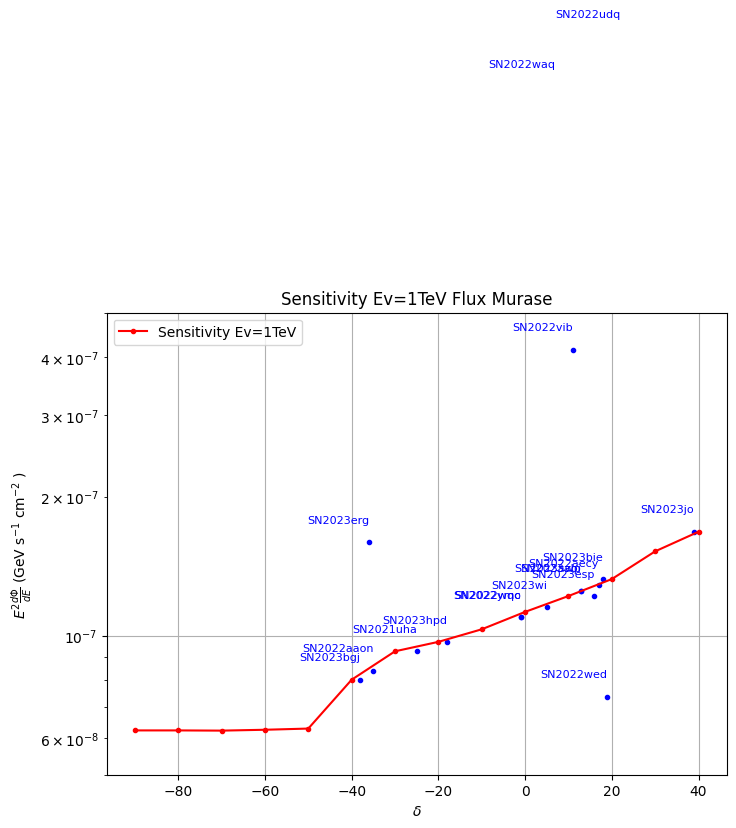

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Funzione di salvataggio dati (puoi personalizzarla se necessario)
def save_data(filename, x, y, header1="", header2=""):
    header = f"{header1}\t{header2}"
    data = np.column_stack((x, y))
    np.savetxt(filename, data, header=header)

# Dati MRF 
MRF_tot = np.array([5.59414,5.07397,4.41866,4.06071,3.75221,3.44035, 3.23166, 3.0832, 2.67603, 2.0977, 2.08528, 2.07631, 2.07851, 2.07851])
#d modello
d = 1 * 3.086e24 #1Mpc in cm
# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12  # eV

# Dati sorgenti SN organizzati in un dizionario
# Per ogni sorgente definiamo: distanza in cm e in m, fattore moltiplicativo per il plot e declinazione
sn_sources = {
    'SN2021uha': {'d_cm': 33.8 * 3.086e24, 'd_m': 33.8 * 3.086e22, 'MRF': 3529.99, 'dec': -25},
    'SN2023esp': {'d_cm': 34.3 * 3.086e24, 'd_m': 34.3 * 3.086e22, 'MRF': 4780.31, 'dec': 16},
    'SN2023erg': {'d_cm': 286.9 * 3.086e24,  'd_m':286.9 * 3.086e22 ,  'MRF': 437578,  'dec': -36},
    'SN2023hpd': {'d_cm': 84.8 * 3.086e24, 'd_m': 84.8 * 3.086e22, 'MRF': 23235,  'dec': -18},
    'SN2023bie': {'d_cm': 265.5 * 3.086e24, 'd_m': 265.5 * 3.086e22, 'MRF': 311473, 'dec': 18},
    'SN2023bgj': {'d_cm': 235.6 * 3.086e24, 'd_m': 235.6 * 3.086e22, 'MRF': 148540, 'dec': -38},
    'SN2023awp': {'d_cm': 58.3 * 3.086e24,  'd_m': 58.3 * 3.086e22,  'MRF': 14173.5, 'dec': 13},
    'SN2023abi': {'d_cm': 394 * 3.086e24,   'd_m': 394 * 3.086e22,   'MRF': 647340, 'dec': 13},
    'SN2023wi':  {'d_cm': 402.6 * 3.086e24, 'd_m': 402.6 * 3.086e22, 'MRF': 623643, 'dec': 5},
    'SN2023jo':  {'d_cm': 55.7 * 3.086e24,  'd_m': 55.7 * 3.086e22,  'MRF': 17355.7, 'dec': 39},
    'SN2022aecy':{'d_cm': 342.6 * 3.086e24, 'd_m': 342.6 * 3.086e22, 'MRF': 503086, 'dec': 17},
    'SN2022aaon':{'d_cm': 316.9 * 3.086e24, 'd_m': 316.9 * 3.086e22, 'MRF': 281258, 'dec': -35},
    'SN2022ymc': {'d_cm': 119.9 * 3.086e24, 'd_m': 119.9 * 3.086e22, 'MRF': 52588.1, 'dec': -1},
    'SN2022wqo': {'d_cm': 400.4 * 3.086e24, 'd_m': 400.4 * 3.086e22, 'MRF':  586458, 'dec': -1},
    'SN2022wed': {'d_cm': 488.2 * 3.086e24, 'd_m': 488.2 * 3.086e22, 'MRF':  586458, 'dec': 19},
    'SN2022waq': {'d_cm': 106.8 * 3.086e24, 'd_m': 106.8 * 3.086e22, 'MRF':  586458, 'dec': 7}, 
    'SN2022vib': {'d_cm': 205.6 * 3.086e24, 'd_m': 205.6 * 3.086e22, 'MRF':  586458, 'dec': 11},
    'SN2022udq': {'d_cm': 94.2 * 3.086e24, 'd_m': 94.2 * 3.086e22, 'MRF':  586458, 'dec': 22}, 
    'SN2022tpe': {'d_cm': 235.6 * 3.086e24, 'd_m': 235.6 * 3.086e22, 'MRF':  586458, 'dec': -40},
    'SN2022tmo': {'d_cm': 145.6 * 3.086e24, 'd_m': 145.6 * 3.086e22, 'MRF':  586458, 'dec': -13},
    'SN2022sks': {'d_cm': 325.5 * 3.086e24, 'd_m': 325.5 * 3.086e22, 'MRF':  586458, 'dec': -51},
    'SN2022saz': {'d_cm': 342.6 * 3.086e24, 'd_m': 342.6 * 3.086e22, 'MRF':  586458, 'dec': 8},
    'SN2022udq': {'d_cm': 94.2 * 3.086e24, 'd_m': 94.2 * 3.086e22, 'MRF':  586458, 'dec': 22},
    'SN2022udq': {'d_cm': 94.2 * 3.086e24, 'd_m': 94.2 * 3.086e22, 'MRF':  586458, 'dec': 22},
    
}

# Caricamento dati dal file
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

if data.shape[1] > 7:
    # Estrazione dati dallo spettro
    Ev_all = data[:, 0]        # Energia in eV
    dN_dEv_all = data[:, 7]      # Spettro

    # Selezione dei dati a bassa energia (per il calcolo di flux_c)
    mask_valid = Ev_all 
    Ev_c = Ev_all[Ev_all==E_fixed] / 1e9   # in GeV
    dN_dEv_c = dN_dEv_all[Ev_all==E_fixed]

    # Selezione dei valori vicini a 1 TeV
    mask_fixed = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_all==E_fixed]
    dN_dEv = dN_dEv_all[Ev_all==E_fixed]

    # Calcolo dell'intervallo delta (se necessario)
    S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
    S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start
    
    flux_c = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
        
    sensitivity_model = flux_c * MRF_tot
    # Funzioni per il calcolo del flux:
    # flux_calculation usa la distanza in cm, mentre flux_c usa la distanza in m
    def flux_calc(Ev_val, dN_dEv_val, d_cm):
        return (Ev_val**2 * dN_dEv_val) / (1e9 * 3 * 4 * np.pi * d_cm**2)
    
    def flux_c_calc(dN_dEv_vals, d_m):
        return (dN_dEv_vals * 1e9) / (6 * 4 * np.pi * d_m**2)
    
    # Calcolo flux e flux_c per ciascuna sorgente
    results = {}
    for sn, params in sn_sources.items():
        f = flux_calc(Ev, dN_dEv, params['d_cm'])
        f_c = flux_c_calc(dN_dEv_c, params['d_m'])
        results[sn] = {'flux': f, 'flux_c': f_c}
    
    # Generazione automatica del nome del file: "flux_c_<nome_supernova>.txt"
        filename = f"flux_c_{sn}.txt"
        save_data(filename, Ev_c, f_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")
        print(f"Dati salvati in {filename}")

    
    # Definizione degli angoli δ per il plot della sensibilità (lungo l'array MRF)
    delta_list = np.linspace(40, -90, len(MRF_tot))
    
    # Preparazione del plot
    plt.figure(figsize=(8, 6))
    plt.yscale("log")
    
    # Plot delle sorgenti con scatter
    for sn, params in sn_sources.items():
        # Si utilizza il flux calcolato e il moltiplicatore specificato per ottenere il valore da plottare
        y_val = np.array(results[sn]['flux'] * params['MRF'])
        x_val = np.array(params['dec'])
        plt.scatter(x_val, y_val, marker='.', color='blue', zorder=1)
        plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='blue', ha='right')
    
    # Plot della sensibilità per SN2023esp (linea rossa)
    plt.plot(delta_list, sensitivity_model, color='red',marker='.', label="Sensitivity Ev=1TeV")
    
    plt.xlabel(r"$\delta$")
    plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
    plt.ylim(5e-8,5e-7)
    plt.grid(True)
    plt.title('Sensitivity Ev=1TeV Flux Murase')
    plt.legend()
    plt.show()

else:
    print("I dati caricati non hanno il numero di colonne richiesto.")


In [2]:
# Calcolare 10^5.8 secondi e convertirli in giorni
seconds = (10**5.8-10**4.9)
days = seconds / (60 * 60 * 24)  # Conversione da secondi a giorni
print(days)


6.383385659812092


In [23]:
seconds = 1e3 * 10**(0.1 * (46.5 - 1)) - 1e3 * 10**(0.1 * (41.5 - 1))
#seconds= 1e3 * 10**(0.1 * (41 - 1))
days = seconds/(60*60*24)
print(days)

280.80039792057755
